In [32]:
import numpy as np
import pandas as pd
import yfinance as yf
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

9731
Date                  0
Ticker                0
mom_1m                0
mom_3m              100
mom_6m              250
mom_12m             546
mom_12m_ex_1m       546
rel_3m_spy          100
rel_6m_spy          250
rel_12m_spy         546
vol_3m              100
vol_6m              250
drawdown_6m         200
drawdown_12m        497
pct_above_200dma    403
adj_close             0
fwd_excess          150
fwd_return          150
dtype: int64


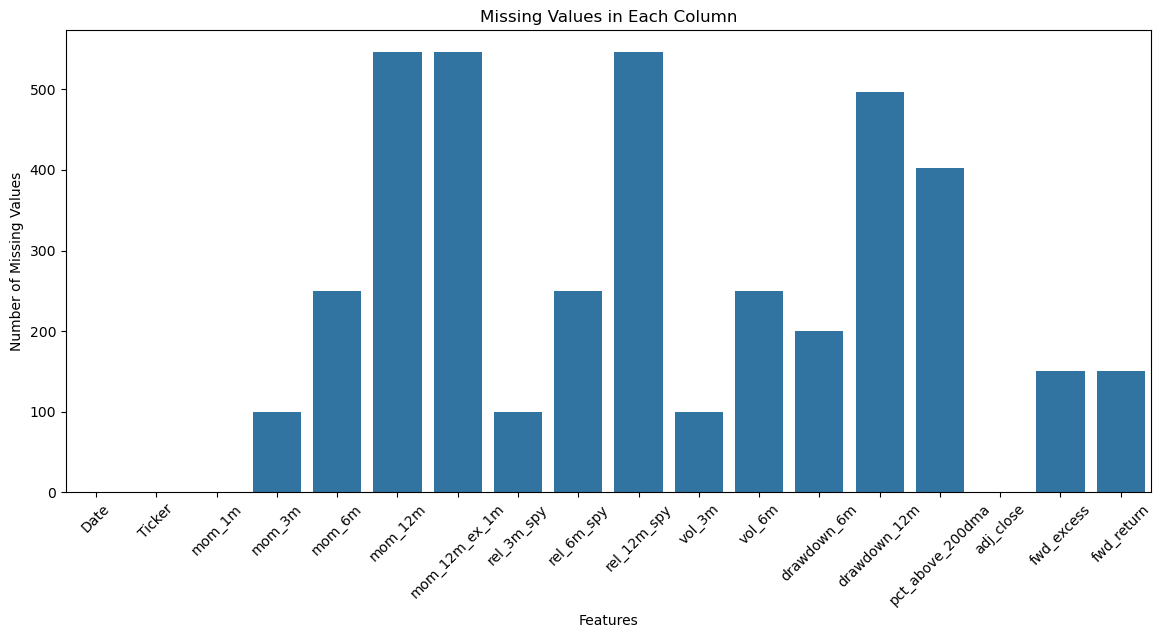

In [ ]:
# Data Path
data_path = "/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Data/final_dataset.csv"

# Load Data
df = pd.read_csv(data_path)
print(len(df.index))
# Check for missing values
print(df.isnull().sum())

# Plot bar plot of the missing values
missing_values = df.isnull().sum()
plt.figure(figsize=(14, 6))
sns.barplot(x=missing_values.index, y=missing_values.values)
plt.xticks(rotation=45)
plt.title("Missing Values in Each Column")
plt.xlabel("Features")
plt.ylabel("Number of Missing Values")
plt.savefig("/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Module4/missing_values_bar_plot.png",
    bbox_inches="tight" # includes labels outside default bounds
)

Date                0.000000
Ticker              0.000000
mom_1m              0.000000
mom_3m              1.027644
mom_6m              2.569109
mom_12m             5.610934
mom_12m_ex_1m       5.610934
rel_3m_spy          1.027644
rel_6m_spy          2.569109
rel_12m_spy         5.610934
vol_3m              1.027644
vol_6m              2.569109
drawdown_6m         2.055287
drawdown_12m        5.107389
pct_above_200dma    4.141404
adj_close           0.000000
fwd_excess          1.541465
fwd_return          1.541465
dtype: float64


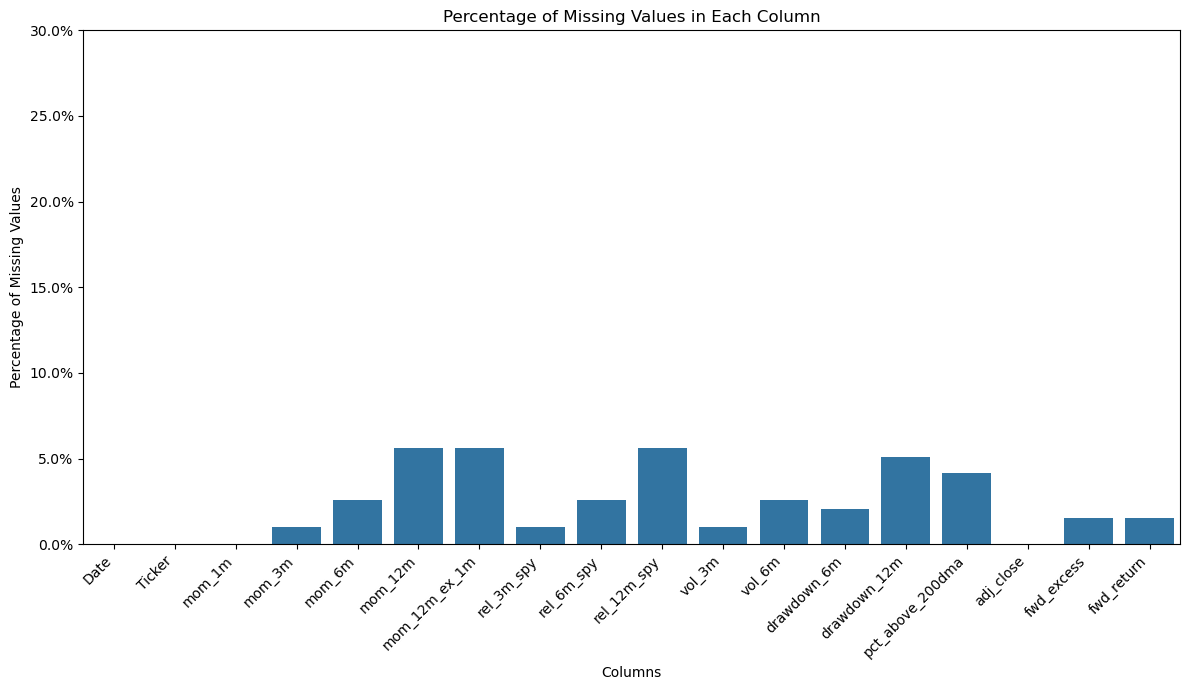

In [34]:
import matplotlib.ticker as mtick

# Nulls Per Column  
nulls_per_column = df.isnull().sum()

# Percentage of Nulls Per Column
percentage_nulls_per_column = (nulls_per_column / len(df)) * 100
print(percentage_nulls_per_column)

plt.figure(figsize=(12, 7))
sns.barplot(x=percentage_nulls_per_column.index, y=percentage_nulls_per_column.values)

plt.xticks(rotation=45, ha="right")
plt.title("Percentage of Missing Values in Each Column")
plt.xlabel("Columns")
plt.ylabel("Percentage of Missing Values")
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
plt.ylim(0, 30)

plt.tight_layout()  # adjusts spacing
plt.savefig(
    "/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Module4/percentage_missing_values_bar_plot.png",
    bbox_inches="tight",  # includes labels outside default bounds
    dpi=300
)
plt.show()

In [ ]:
# check if there are duplicate rows
num_dupes = df.duplicated().sum()

if num_dupes > 0:
    print("Duplicate rows found. Consider removing them.")
    # View duplicate rows
    dupe_rows = df[df.duplicated()]
    print(dupe_rows)
else:
    print("No duplicate rows found.")

# check if there are duplicate columns
dup_content_mask = df.T.duplicated().sum()

if dup_content_mask > 0:
    print("Duplicate columns found. Consider removing them.")
    # View duplicate columns
    dupe_cols = df.columns[df.T.duplicated()]
    print(dupe_cols)
else:
    print("No duplicate columns found.")

No duplicate rows found.
No duplicate columns found.


In [ ]:

# Transpose the DataFrame and check for duplicated columns (rows)
dup_content_mask = df.T.duplicated()
dup_content_cols = df.columns[dup_content_mask]
print(f"Duplicate columns by content: {dup_content_cols.tolist()}")

Duplicate columns by content: []


In [45]:
# preprocess the data by dropping rows with missing values
print("Missing fwd_excess values:")
print(df[["Date","Ticker","fwd_excess"]].tail(5))

df_dropped = df.dropna()
print("---  ---  ---")
print("Length of original:",len(df.index))
print("Length of dropped:",len(df_dropped.index))
print("Sanity check - missing fwd_excess values after dropping:")
print(df_dropped[["Date","Ticker","fwd_excess"]].tail(5))



Missing fwd_excess values:
            Date Ticker  fwd_excess
9726  2026-02-28    NVS         NaN
9727  2026-02-28    AXP         NaN
9728  2026-02-28    NVO         NaN
9729  2026-02-28     PM         NaN
9730  2026-02-28    RTX         NaN
---  ---  ---
Length of original: 9731
Length of dropped: 9038
Sanity check - missing fwd_excess values after dropping:
            Date Ticker  fwd_excess
9576  2025-11-30    NVS    0.236199
9577  2025-11-30    AXP   -0.059055
9578  2025-11-30    NVO   -0.008354
9579  2025-11-30     PM    0.210935
9580  2025-11-30    RTX    0.150119


In [47]:
# Log the Adjusted Close
print(df_dropped["adj_close"].describe())
print("---  ---  ---")

df_dropped["log_adj_close"] = np.log(df_dropped["adj_close"])
print(df_dropped[["Date","Ticker","adj_close","log_adj_close"]].tail(10))

count    9038.000000
mean      100.666846
std       123.299178
min         0.210643
25%        30.451757
50%        61.107658
75%       120.027697
max      1075.469971
Name: adj_close, dtype: float64
---  ---  ---
            Date Ticker   adj_close  log_adj_close
9571  2025-11-30    IBM  306.830597       5.726296
9572  2025-11-30     GS  821.965088       6.711698
9573  2025-11-30    MRK  103.941612       4.643829
9574  2025-11-30   LRCX  155.743591       5.048211
9575  2025-11-30   HSBC   71.160004       4.264931
9576  2025-11-30    NVS  130.399994       4.870607
9577  2025-11-30    AXP  364.460358       5.898418
9578  2025-11-30    NVO   49.349998       3.898938
9579  2025-11-30     PM  156.056625       5.050219
9580  2025-11-30    RTX  174.910004       5.164272


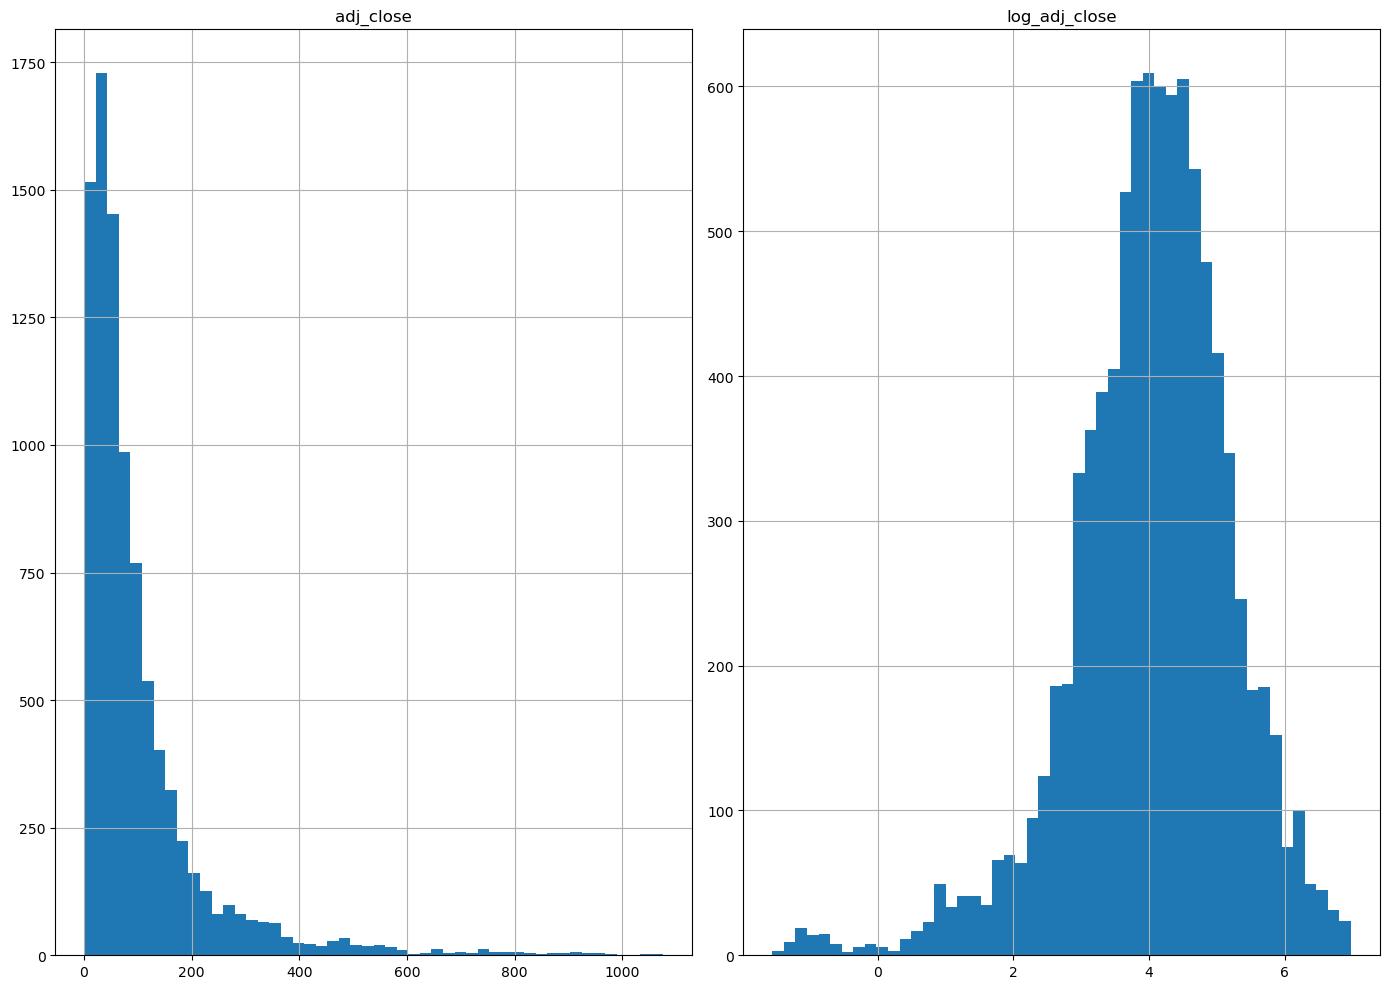

In [49]:
# Histogram of variables
cols = df_dropped.columns.drop(['fwd_excess','Date'])
df_dropped[["adj_close","log_adj_close"]].hist(figsize=(14, 10), bins=50)
plt.tight_layout()
plt.savefig('/Users/christoomey/Desktop/Courses/ADAN8888_Applied_Analytics_Project/Module4/log_hist.png') 
plt.show()